✅ Classical dataset ready: (600, 10)


,Date,State,Temperature_C,Precip_mm,Humidity_%,NDVI,Soil_Moisture,Land_Use_Index,Zoonotic_Risk_Score,Alert_Level
0,2015-01-15,Rajasthan,30.820515,11.512652,45.911222,0.216525,0.156703,0.399052,0.518470,Moderate
1,2015-02-15,Rajasthan,32.387946,11.524666,46.273807,0.121551,0.173168,0.410530,0.498407,Moderate
2,2015-03-15,Rajasthan,28.259409,12.966183,39.727656,0.313913,0.180717,0.535823,0.474161,Moderate
3,2015-04-15,Rajasthan,32.111525,13.938677,29.002009,0.245557,0.096661,0.424256,0.390641,Moderate
4,2015-05-15,Rajasthan,26.835954,13.425812,25.790260,0.217013,0.151195,0.526381,0.465173,Moderate


<Figure size 900x500 with 0 Axes>

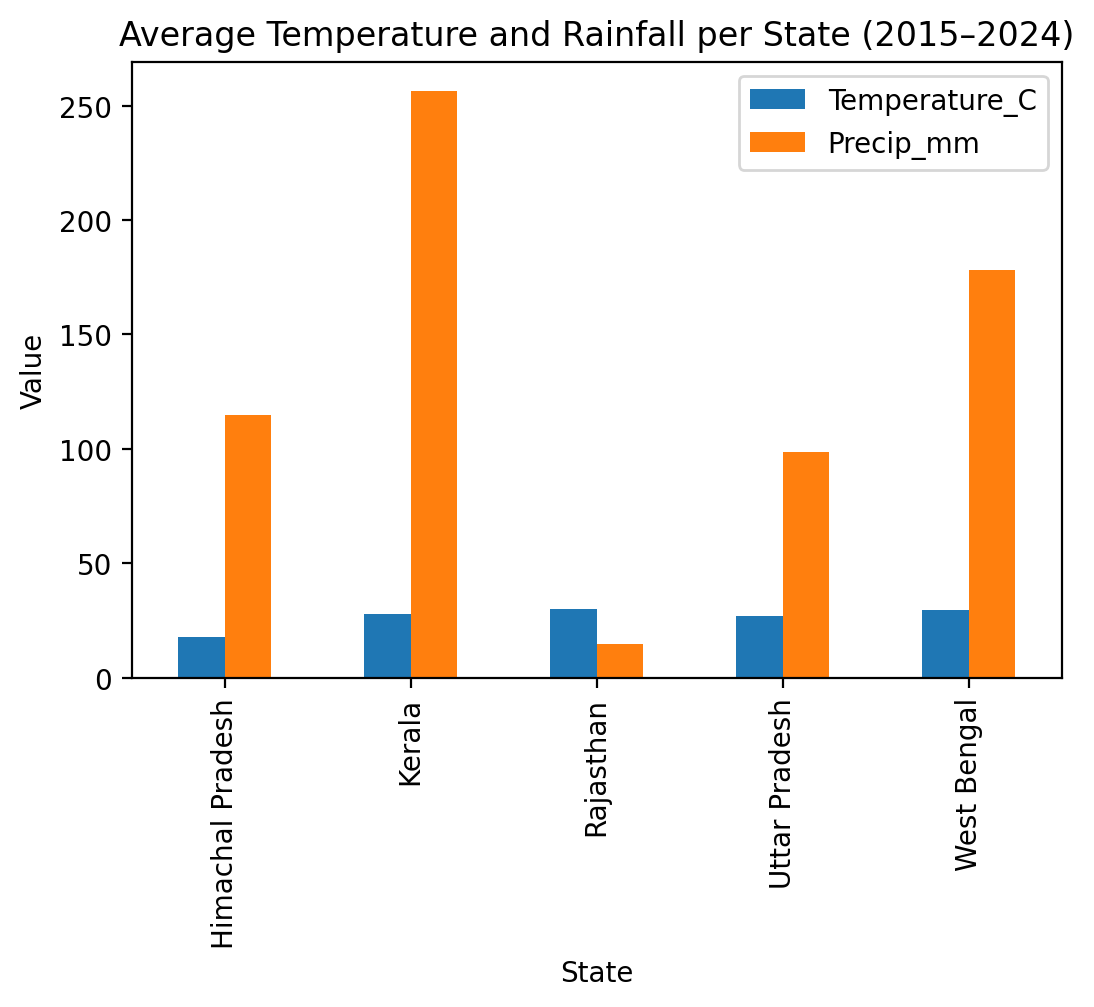

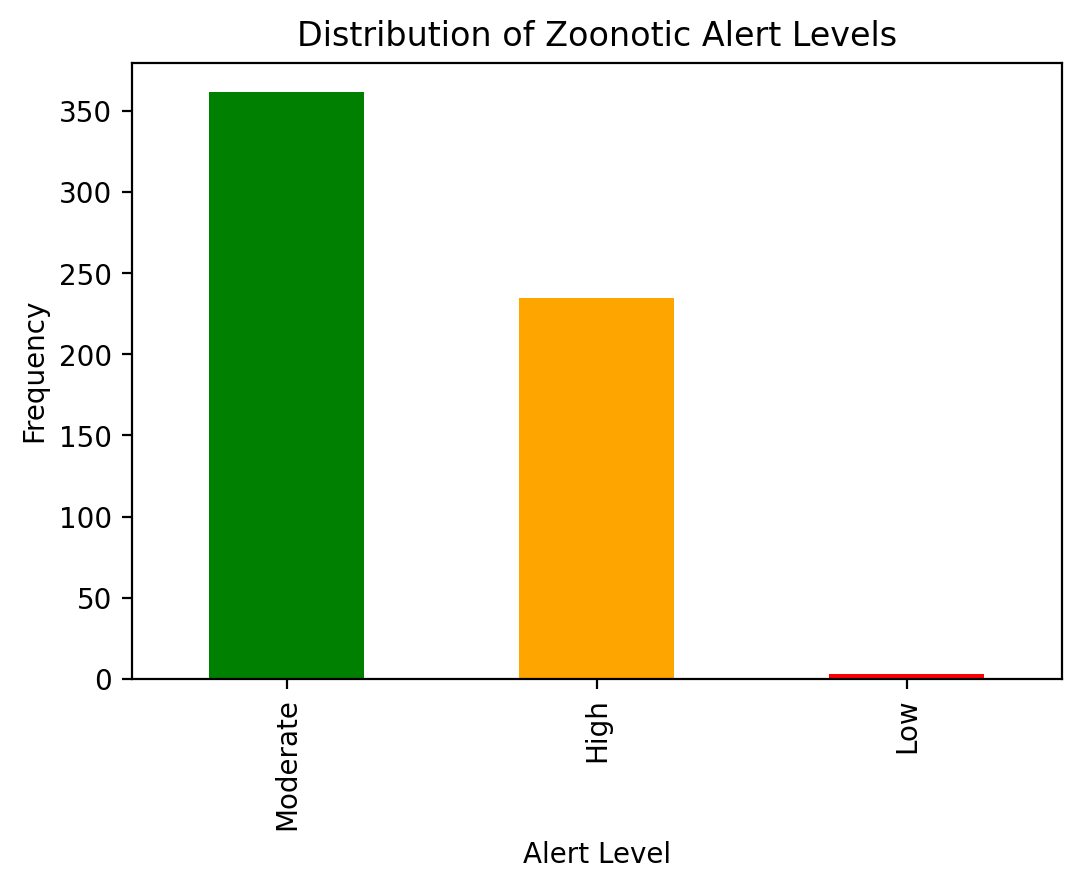

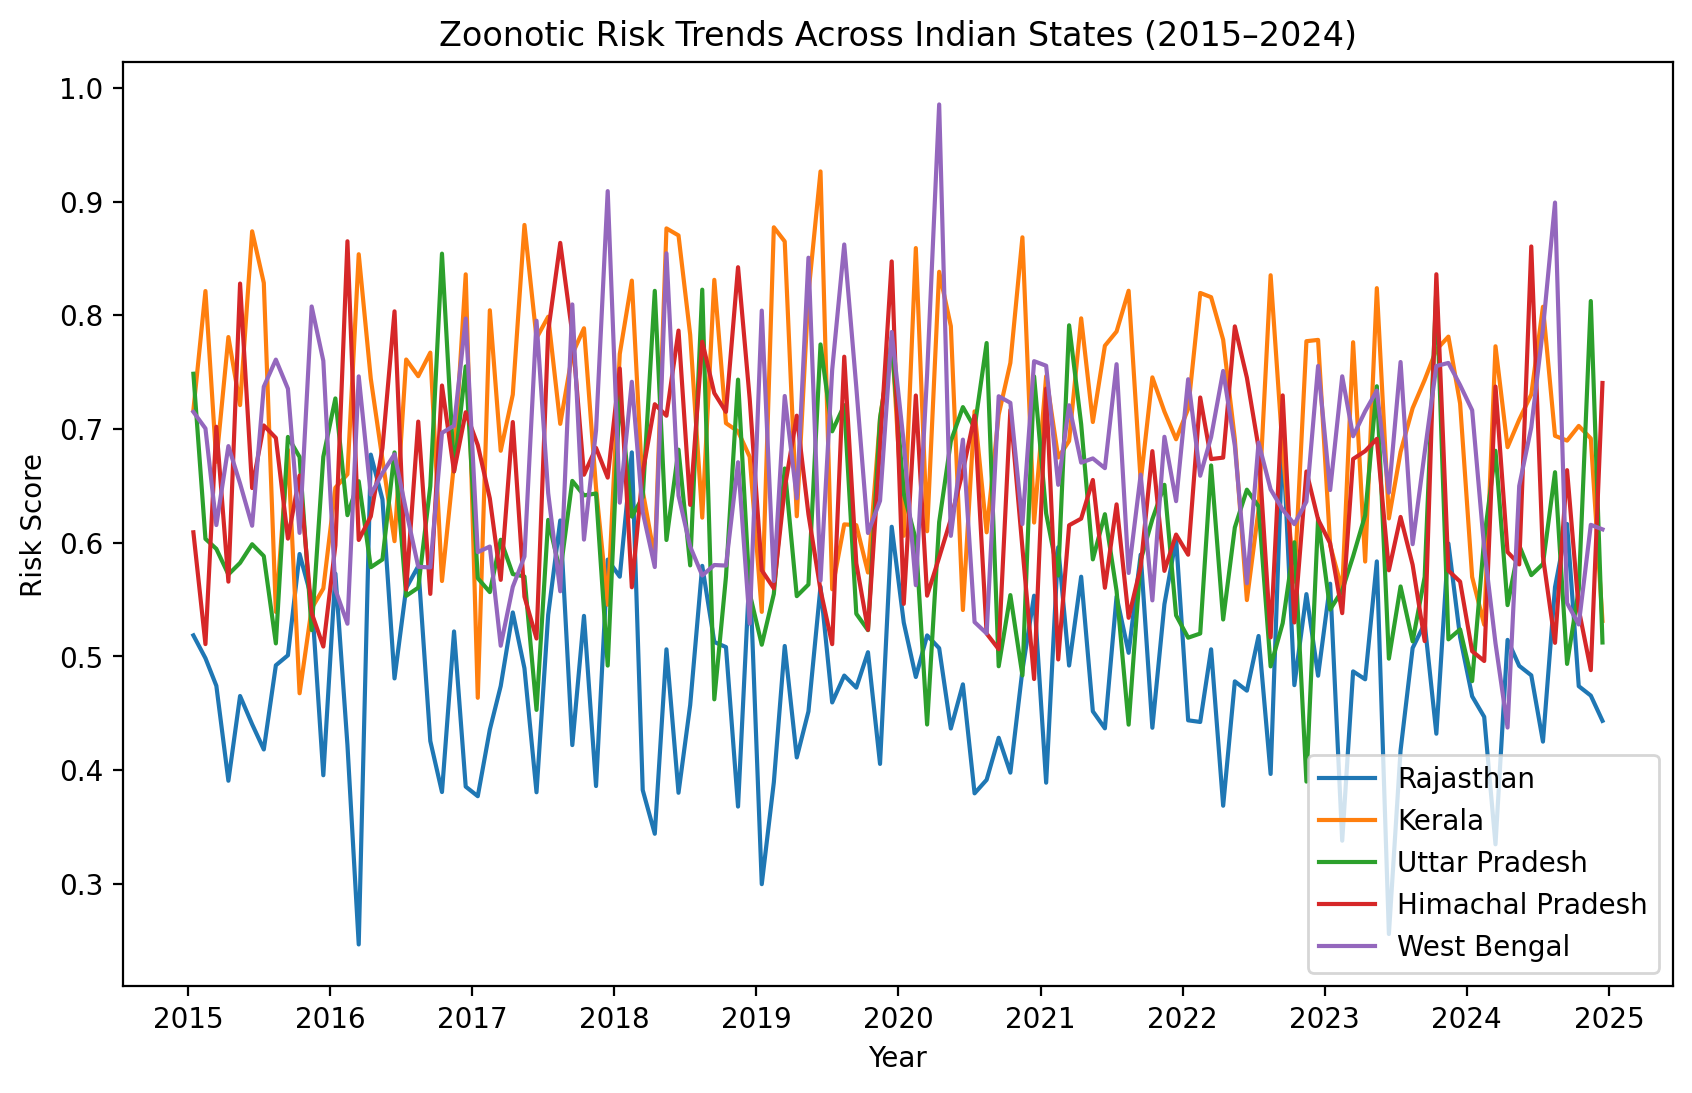

In [36]:
# ==========================================
# Classical Machine Learning Dataset + Graphs
# ==========================================
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --- Generate synthetic data for 5 representative Indian states ---
states = {
    'Rajasthan': {'temp': 30, 'rain': 15, 'humid': 35, 'ndvi': 0.25, 'soil': 0.15, 'land': 0.45},
    'Kerala': {'temp': 28, 'rain': 250, 'humid': 80, 'ndvi': 0.75, 'soil': 0.55, 'land': 0.60},
    'Uttar Pradesh': {'temp': 27, 'rain': 100, 'humid': 60, 'ndvi': 0.50, 'soil': 0.40, 'land': 0.55},
    'Himachal Pradesh': {'temp': 18, 'rain': 120, 'humid': 55, 'ndvi': 0.65, 'soil': 0.50, 'land': 0.35},
    'West Bengal': {'temp': 29, 'rain': 180, 'humid': 75, 'ndvi': 0.70, 'soil': 0.45, 'land': 0.65}
}

years = range(2015, 2025)
months = range(1, 13)
rows = []

for state, vals in states.items():
    for y in years:
        for m in months:
            temp = np.random.normal(vals['temp'], 3)
            rain = np.random.normal(vals['rain'], vals['rain'] * 0.25)
            humid = np.clip(np.random.normal(vals['humid'], 8), 20, 100)
            ndvi = np.clip(np.random.normal(vals['ndvi'], 0.08), 0, 1)
            soil = np.clip(np.random.normal(vals['soil'], 0.05), 0, 1)
            land = np.clip(np.random.normal(vals['land'], 0.05), 0, 1)
            risk = np.clip(
                (rain / (vals['rain'] + 1)) * 0.3 +
                (humid / 100) * 0.25 + ndvi * 0.15 +
                soil * 0.1 + (1 - land) * 0.1 +
                np.random.uniform(-0.1, 0.1),
                0, 1
            )
            alert = "Low" if risk < 0.33 else ("Moderate" if risk < 0.66 else "High")
            rows.append([dt.date(y, m, 15), state, temp, rain, humid, ndvi, soil, land, risk, alert])

# --- Create DataFrame ---
classical_df = pd.DataFrame(rows, columns=[
    'Date', 'State', 'Temperature_C', 'Precip_mm', 'Humidity_%',
    'NDVI', 'Soil_Moisture', 'Land_Use_Index', 'Zoonotic_Risk_Score', 'Alert_Level'
])
print("✅ Classical dataset ready:", classical_df.shape)
display(classical_df.head())

# --- Graph 1: Average Climate per State ---
plt.figure(figsize=(9,5))
classical_df.groupby("State")[["Temperature_C","Precip_mm"]].mean().plot(kind="bar")
plt.title("Average Temperature and Rainfall per State (2015–2024)")
plt.xlabel("State")
plt.ylabel("Value")
plt.legend()
plt.show()

# --- Graph 2: Alert Level Distribution ---
plt.figure(figsize=(6,4))
classical_df["Alert_Level"].value_counts().plot(kind="bar", color=["green","orange","red"])
plt.title("Distribution of Zoonotic Alert Levels")
plt.xlabel("Alert Level")
plt.ylabel("Frequency")
plt.show()

# --- Graph 3: Risk Trend for All States ---
plt.figure(figsize=(10,6))
for state in classical_df["State"].unique():
    df_state = classical_df[classical_df["State"] == state]
    plt.plot(df_state["Date"], df_state["Zoonotic_Risk_Score"], label=state)
plt.title("Zoonotic Risk Trends Across Indian States (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Risk Score")
plt.legend()
plt.show()
